In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import cartopy.crs as ccrs
import xarray as xr
# import cmocean.cm as cmocean
import glob
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.path as mpath
import matplotlib.colors as col
from netCDF4 import Dataset
import cmocean as cmo


import logging
logging.captureWarnings(True)
logging.getLogger('py.warnings').setLevel(logging.ERROR)

from dask.distributed import Client

figdir = '/g/data/e14/fbd581/basal_mom5-collaborative-project/'

In [2]:
import intake
from access_nri_intake.source.builders import AccessOm2Builder


In [3]:
client = Client(threads_per_worker=1)
client.dashboard_link

'/proxy/34325/status'

## Surface heat/FW budget

This script reads shelf-integrasted heat and freshwater budget diagnostics processed individually from:
- fw_budget/FW_budget_shelf_SOFIA.ipynb
- heat_budget/Heat_budget_shelf_SOFIA.ipynb

It also includes budget integrated for individual DSW formation regions:

    ## Larger regions:
        # 'Ross':    {'lon': slice(-200, -160), 'lat': slice(-80, -70)},
        # 'Adelie':  {'lon': slice(-240, -210), 'lat': slice(-70, -65)},
        # 'Prydz':   {'lon': slice(58, 73),     'lat': slice(-70, -65)},
        # 'Weddell': {'lon': slice(-65, -30),   'lat': slice(-78, -70)}
    ## smaller regions:
        'Ross':    {'lon': slice(-200, -175), 'lat': slice(-80, -70)},
        'Adelie':  {'lon': slice(-230, -220), 'lat': slice(-70, -65)},
        'Prydz':   {'lon': slice(65, 70),     'lat': slice(-70, -65)},
        'Weddell': {'lon': slice(-50, -40),   'lat': slice(-78, -70)}

'Winter' subscript means average between July-October, otherwise it refers to annual mean.

### Buoyancy budget:

B = g ( alpha Q (rho0 Cp)^-1  -  beta S0 Fv)

where:

B [m^2.s^3]

Q = Heat flux (W)

Fv = Fw/rho_FW

-> being Fw the FW volume flux  in m^3.s^-1, and rho_FW = 100 kg.m^-3

rho0 = 1023 kg.m^-3

Cp = 3985 J.kg^-1.K^-1

g = 9.81 m^2.s^-1

S0 = reference salinity



### Read circum-Antarctic integral

In [4]:
budget_dir = '/g/data/e14/fbd581/basal_mom5-collaborative-project/budget_integrated_circum-Antarctic/'


In [5]:
import os

datasets = {}

for f in glob.glob(budget_dir + '*.nc'):

    key = os.path.basename(f).replace('.nc','')

    datasets[key] = xr.open_dataset(f)

In [6]:
def val(term, exp):

    dsname = f'{term}_annual_hint_shelf_{exp}'

    return datasets[dsname].to_dataarray().values


Read FW budget terms:

In [7]:
# NET
FW_net_ctrl = val('pme_river','ctrl')
FW_net_ctrl_a = val('pme_river','ctrl_a')
FW_net_ctrl_a_BG = val('pme_river','ctrl_a_BG') + val('basal','ctrl_a_BG') + val('brine','ctrl_a_BG')
FW_net_ctrlBG_a = val('pme_river','ctrlBG_a') + val('basal','ctrlBG_a') + val('brine','ctrlBG_a')
FW_net_BGB = val('pme_river','BGB') + val('basal','BGB') + val('brine','BGB')
FW_net_BGB_a = val('pme_river','BGB_a') + val('basal','BGB_a') + val('brine','BGB_a')

# PME
pme_ctrl = val('pme_net','ctrl') - (val('wfiform','ctrl') + val('wfimelt','ctrl'))
pme_ctrl_a = val('pme_net','ctrl_a')  - (val('wfiform','ctrl_a') + val('wfimelt','ctrl_a'))
pme_ctrl_a_BG = val('pme_net','ctrl_a_BG') + val('brine','ctrl_a_BG') - (val('wfiform','ctrl_a_BG') + val('wfimelt','ctrl_a_BG'))
pme_ctrlBG_a = val('pme_net','ctrlBG_a') + val('brine','ctrlBG_a') - (val('wfiform','ctrlBG_a') + val('wfimelt','ctrlBG_a'))
pme_BGB = val('pme_net','BGB') + val('brine','BGB')  - (val('wfiform','BGB') + val('wfimelt','BGB'))
pme_BGB_a = val('pme_net','BGB_a') + val('brine','BGB_a')  - (val('wfiform','BGB_a') + val('wfimelt','BGB_a'))

# Runoff
runoff_ctrl = val('river','ctrl')
runoff_ctrl_a = val('river','ctrl_a')
runoff_ctrl_a_BG = val('river','ctrl_a_BG') + val('basal','ctrl_a_BG')
runoff_ctrlBG_a = val('river','ctrlBG_a') + val('basal','ctrlBG_a')
runoff_BGB = val('river','BGB') + val('basal','BGB')
runoff_BGB_a = val('river','BGB_a') + val('basal','BGB_a')

# Sea ice (net)
FW_SI_ctrl = (val('wfiform','ctrl') + val('wfimelt','ctrl'))
FW_SI_ctrl_a = (val('wfiform','ctrl_a') + val('wfimelt','ctrl_a'))
FW_SI_ctrl_a_BG = (val('wfiform','ctrl_a_BG') + val('wfimelt','ctrl_a_BG'))
FW_SI_ctrlBG_a = (val('wfiform','ctrlBG_a') + val('wfimelt','ctrlBG_a'))
FW_SI_BGB = (val('wfiform','BGB') + val('wfimelt','BGB'))
FW_SI_BGB_a = (val('wfiform','BGB_a') + val('wfimelt','BGB_a'))

# Sea ice (formation)
SIf_ctrl = (val('wfiform','ctrl') )
SIf_ctrl_a = (val('wfiform','ctrl_a') )
SIf_ctrl_a_BG = (val('wfiform','ctrl_a_BG') )
SIf_ctrlBG_a = (val('wfiform','ctrlBG_a') )
SIf_BGB = (val('wfiform','BGB') )
SIf_BGB_a = (val('wfiform','BGB_a') )
# Sea ice (melting)
SIm_ctrl = (val('wfimelt','ctrl') )
SIm_ctrl_a = (val('wfimelt','ctrl_a') )
SIm_ctrl_a_BG = (val('wfimelt','ctrl_a_BG') )
SIm_ctrlBG_a = (val('wfimelt','ctrlBG_a') )
SIm_BGB = (val('wfimelt','BGB') )
SIm_BGB_a = (val('wfimelt','BGB_a') )

# SSS restoring
SSSrest_ctrl = val('FW_restore','ctrl')
SSSrest_ctrl_a = val('FW_restore','ctrl_a')
SSSrest_ctrl_a_BG = val('FW_restore','ctrl_a_BG')
SSSrest_ctrlBG_a = val('FW_restore','ctrlBG_a')
SSSrest_BGB = val('FW_restore','BGB')
SSSrest_BGB_a = val('FW_restore','BGB_a')

# FW from ice
Ice_ctrl = val('FW_ice','ctrl')
Ice_ctrl_a = val('FW_ice','ctrl_a')
Ice_ctrl_a_BG = val('FW_ice','ctrl_a_BG')
Ice_ctrlBG_a = val('FW_ice','ctrlBG_a')
Ice_BGB = val('FW_ice','BGB')
Ice_BGB_a = val('FW_ice','BGB_a')

Read heat budget terms:

In [8]:
# Runoff
HF_runoff_ctrl = val('HF_runoff','ctrl')
HF_runoff_ctrl_a = val('HF_runoff','ctrl_a')
HF_runoff_ctrl_a_BG = val('HF_runoff','ctrl_a_BG') 
HF_runoff_ctrlBG_a = val('HF_runoff','ctrlBG_a') 
HF_runoff_BGB = val('HF_runoff','BGB') 
HF_runoff_BGB_a = val('HF_runoff','BGB_a')

# Atmosp. (excl. SI)
HF_coupler_ctrl = val('HF_coupler','ctrl') - val('HF_mh','ctrl')
HF_coupler_ctrl_a = val('HF_coupler','ctrl_a') - val('HF_mh','ctrl_a')
HF_coupler_ctrl_a_BG = val('HF_coupler','ctrl_a_BG') - val('HF_mh','ctrl_a_BG')
HF_coupler_ctrlBG_a = val('HF_coupler','ctrlBG_a') - val('HF_mh','ctrlBG_a')
HF_coupler_BGB = val('HF_coupler','BGB') - val('HF_mh','BGB')
HF_coupler_BGB_a = val('HF_coupler','BGB_a') - val('HF_mh','BGB_a')

# basalmix
HF_basal_ctrl_a_BG = val('HF_basalmix','ctrl_a_BG')
HF_basal_ctrlBG_a = val('HF_basalmix','ctrlBG_a')
HF_basal_BGB = val('HF_basalmix','BGB')
HF_basal_BGB_a = val('HF_basalmix','BGB_a')

# PME
HF_pme_ctrl = val('HF_pme','ctrl') 
HF_pme_ctrl_a = val('HF_pme','ctrl_a')  
HF_pme_ctrl_a_BG = val('HF_pme','ctrl_a_BG') 
HF_pme_ctrlBG_a = val('HF_pme','ctrlBG_a') 
HF_pme_BGB = val('HF_pme','BGB') 
HF_pme_BGB_a = val('HF_pme','BGB_a') 

# Frazil
HF_frazil_ctrl = val('HF_frazil','ctrl')
HF_frazil_ctrl_a = val('HF_frazil','ctrl_a')
HF_frazil_ctrl_a_BG = val('HF_frazil','ctrl_a_BG')
HF_frazil_ctrlBG_a = val('HF_frazil','ctrlBG_a')
HF_frazil_BGB = val('HF_frazil','BGB')
HF_frazil_BGB_a = val('HF_frazil','BGB_a')

# Sea-ice
HF_mh_ctrl = val('HF_mh','ctrl')
HF_mh_ctrl_a = val('HF_mh','ctrl_a')
HF_mh_ctrl_a_BG = val('HF_mh','ctrl_a_BG')
HF_mh_ctrlBG_a = val('HF_mh','ctrlBG_a')
HF_mh_BGB = val('HF_mh','BGB')
HF_mh_BGB_a = val('HF_mh','BGB_a')


# NET
HF_net_ctrl = HF_runoff_ctrl + HF_coupler_ctrl + HF_pme_ctrl + HF_frazil_ctrl
HF_net_ctrl_a = HF_runoff_ctrl_a + HF_coupler_ctrl_a + HF_pme_ctrl_a + HF_frazil_ctrl_a
HF_net_ctrl_a_BG = HF_runoff_ctrl_a_BG + HF_coupler_ctrl_a_BG + HF_pme_ctrl_a_BG + HF_frazil_ctrl_a_BG + HF_basal_ctrl_a_BG
HF_net_ctrlBG_a = HF_runoff_ctrlBG_a + HF_coupler_ctrlBG_a + HF_pme_ctrlBG_a + HF_frazil_ctrlBG_a + HF_basal_ctrlBG_a
HF_net_BGB = HF_runoff_BGB + HF_coupler_BGB + HF_pme_BGB + HF_frazil_BGB + HF_basal_BGB
HF_net_BGB_a = HF_runoff_BGB_a + HF_coupler_BGB_a + HF_pme_BGB_a + HF_frazil_BGB_a + HF_basal_BGB_a

Calculate buoyancy budget for the net terms (using both heat and FW):


In [9]:
HF_net_ctrl

array([-2.3816802e+13], dtype=float32)

In [10]:
FW_net_ctrl

array([-3.0540234e+08], dtype=float32)

In [11]:
## define constants:
rhoFW = 1000
rho0 = 1027
Cp = 3991
g = 9.81
So = 34
alpha = 1.7e-4
beta = 7.5e-4

In [12]:
## testing:

BH = (g*alpha/(rho0*Cp))*HF_net_ctrl
BFW = (g*beta*So/rhoFW)*(FW_net_ctrl)
print(BH, BFW)

[-9690.567] [-76397.92]


In [13]:
# define heat and FW constants (so I just multiply it by each term):
heat_cte = (g*alpha/(rho0*Cp))
fw_cte = (g*beta*So/rhoFW)

#### Combine terms:


In [14]:
# ctrl
NET_BH_ctrl = HF_net_ctrl*heat_cte 
NET_BFW_ctrl = FW_net_ctrl*fw_cte
NET_ctrl = NET_BH_ctrl + NET_BFW_ctrl

RUNOFF_BH_ctrl = HF_runoff_ctrl*heat_cte 
RUNOFF_BFW_ctrl = (runoff_ctrl)*fw_cte           
RUNOFF_ctrl = RUNOFF_BH_ctrl + RUNOFF_BFW_ctrl

PME_BH_ctrl = HF_pme_ctrl*heat_cte
PME_BFW_ctrl = pme_ctrl*fw_cte 
PME_ctrl = PME_BH_ctrl + PME_BFW_ctrl

SI_BH_ctrl = HF_mh_ctrl*heat_cte
SI_BFW_ctrl = FW_SI_ctrl*fw_cte
SI_ctrl = SI_BH_ctrl + SI_BFW_ctrl

FRAZIL_BH_ctrl = HF_frazil_ctrl*heat_cte

SSSrest_BFW_ctrl = SSSrest_ctrl*fw_cte

In [15]:
# ctrl_a
NET_BH_ctrl_a = HF_net_ctrl_a*heat_cte 
NET_BFW_ctrl_a = FW_net_ctrl_a*fw_cte
NET_ctrl_a = NET_BH_ctrl_a + NET_BFW_ctrl_a

RUNOFF_BH_ctrl_a = HF_runoff_ctrl_a*heat_cte 
RUNOFF_BFW_ctrl_a = (runoff_ctrl_a)*fw_cte           
RUNOFF_ctrl_a = RUNOFF_BH_ctrl_a + RUNOFF_BFW_ctrl_a

PME_BH_ctrl_a = HF_pme_ctrl_a*heat_cte
PME_BFW_ctrl_a = pme_ctrl_a*fw_cte 
PME_ctrl_a = PME_BH_ctrl_a + PME_BFW_ctrl_a

SI_BH_ctrl_a = HF_mh_ctrl_a*heat_cte
SI_BFW_ctrl_a = FW_SI_ctrl_a*fw_cte
SI_ctrl_a = SI_BH_ctrl_a + SI_BFW_ctrl_a

FRAZIL_BH_ctrl_a = HF_frazil_ctrl_a*heat_cte

SSSrest_BFW_ctrl_a = SSSrest_ctrl_a*fw_cte

In [16]:
# ctrl_a_BG
NET_BH_ctrl_a_BG = HF_net_ctrl_a_BG*heat_cte 
NET_BFW_ctrl_a_BG = FW_net_ctrl_a_BG*fw_cte
NET_ctrl_a_BG = NET_BH_ctrl_a_BG + NET_BFW_ctrl_a_BG

RUNOFF_BH_ctrl_a_BG = HF_runoff_ctrl_a_BG*heat_cte + HF_basal_ctrl_a_BG*heat_cte
RUNOFF_BFW_ctrl_a_BG = (runoff_ctrl_a_BG)*fw_cte           
RUNOFF_ctrl_a_BG = RUNOFF_BH_ctrl_a_BG + RUNOFF_BFW_ctrl_a_BG

PME_BH_ctrl_a_BG = HF_pme_ctrl_a_BG*heat_cte
PME_BFW_ctrl_a_BG = pme_ctrl_a_BG*fw_cte 
PME_ctrl_a_BG = PME_BH_ctrl_a_BG + PME_BFW_ctrl_a_BG

SI_BH_ctrl_a_BG = HF_mh_ctrl_a_BG*heat_cte
SI_BFW_ctrl_a_BG = FW_SI_ctrl_a_BG*fw_cte
SI_ctrl_a_BG = SI_BH_ctrl_a_BG + SI_BFW_ctrl_a_BG

FRAZIL_BH_ctrl_a_BG = HF_frazil_ctrl_a_BG*heat_cte

SSSrest_BFW_ctrl_a_BG = SSSrest_ctrl_a_BG*fw_cte

In [17]:
# ctrlBG_a
NET_BH_ctrlBG_a = HF_net_ctrlBG_a*heat_cte 
NET_BFW_ctrlBG_a = FW_net_ctrlBG_a*fw_cte
NET_ctrlBG_a = NET_BH_ctrlBG_a + NET_BFW_ctrlBG_a

RUNOFF_BH_ctrlBG_a = HF_runoff_ctrlBG_a*heat_cte + HF_basal_ctrlBG_a*heat_cte
RUNOFF_BFW_ctrlBG_a = (runoff_ctrlBG_a)*fw_cte           
RUNOFF_ctrlBG_a = RUNOFF_BH_ctrlBG_a + RUNOFF_BFW_ctrlBG_a

PME_BH_ctrlBG_a = HF_pme_ctrlBG_a*heat_cte
PME_BFW_ctrlBG_a = pme_ctrlBG_a*fw_cte 
PME_ctrlBG_a = PME_BH_ctrlBG_a + PME_BFW_ctrlBG_a

SI_BH_ctrlBG_a = HF_mh_ctrlBG_a*heat_cte
SI_BFW_ctrlBG_a = FW_SI_ctrlBG_a*fw_cte
SI_ctrlBG_a = SI_BH_ctrlBG_a + SI_BFW_ctrlBG_a

FRAZIL_BH_ctrlBG_a = HF_frazil_ctrlBG_a*heat_cte

SSSrest_BFW_ctrlBG_a = SSSrest_ctrlBG_a*fw_cte

In [18]:
# BGB
NET_BH_BGB = HF_net_BGB*heat_cte 
NET_BFW_BGB = FW_net_BGB*fw_cte
NET_BGB = NET_BH_BGB + NET_BFW_BGB

RUNOFF_BH_BGB = HF_runoff_BGB*heat_cte + HF_basal_BGB*heat_cte
RUNOFF_BFW_BGB = (runoff_BGB)*fw_cte           
RUNOFF_BGB = RUNOFF_BH_BGB + RUNOFF_BFW_BGB

PME_BH_BGB = HF_pme_BGB*heat_cte
PME_BFW_BGB = pme_BGB*fw_cte 
PME_BGB = PME_BH_BGB + PME_BFW_BGB

SI_BH_BGB = HF_mh_BGB*heat_cte
SI_BFW_BGB = FW_SI_BGB*fw_cte
SI_BGB = SI_BH_BGB + SI_BFW_BGB

FRAZIL_BH_BGB = HF_frazil_BGB*heat_cte

SSSrest_BFW_BGB = SSSrest_BGB*fw_cte

In [19]:
# BGB_a
NET_BH_BGB_a = HF_net_BGB_a*heat_cte 
NET_BFW_BGB_a = FW_net_BGB_a*fw_cte
NET_BGB_a = NET_BH_BGB_a + NET_BFW_BGB_a

RUNOFF_BH_BGB_a = HF_runoff_BGB_a*heat_cte + HF_basal_BGB_a*heat_cte
RUNOFF_BFW_BGB_a = (runoff_BGB_a)*fw_cte           
RUNOFF_BGB_a = RUNOFF_BH_BGB_a + RUNOFF_BFW_BGB_a

PME_BH_BGB_a = HF_pme_BGB_a*heat_cte
PME_BFW_BGB_a = pme_BGB_a*fw_cte 
PME_BGB_a = PME_BH_BGB_a + PME_BFW_BGB_a

SI_BH_BGB_a = HF_mh_BGB_a*heat_cte
SI_BFW_BGB_a = FW_SI_BGB_a*fw_cte
SI_BGB_a = SI_BH_BGB_a + SI_BFW_BGB_a

FRAZIL_BH_BGB_a = HF_frazil_BGB_a*heat_cte

SSSrest_BFW_BGB_a = SSSrest_BGB_a*fw_cte

#### Bar plot with buoytance budget:

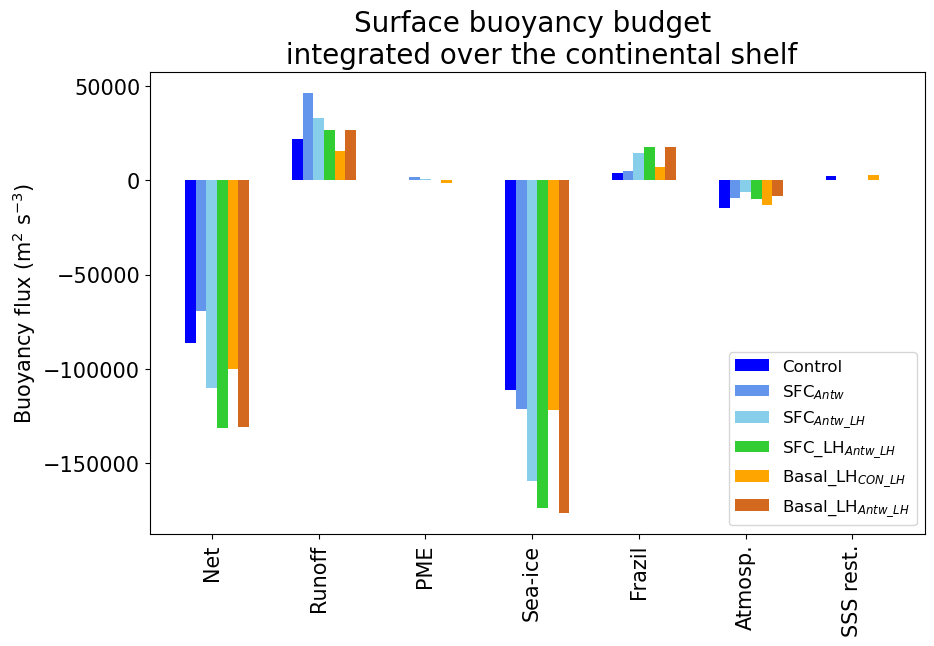

In [20]:
import matplotlib.pyplot as pyplot

fig, ax  = plt.subplots(figsize = (10,6))

pyplot.bar(-.2,  NET_ctrl, width=0.1, color='blue', label='Control',alpha=1)
# pyplot.bar(-.2,  NET_BFW_ctrl, hatch="\\", width=0.1, color='blue', label='Control/FW',alpha=1)
# pyplot.bar(-.2,  NET_BH_ctrl, hatch="O", width=0.1, color='blue', label='Control/Heat',alpha=1)
pyplot.bar(-.1,  NET_ctrl_a, width=0.1, color='cornflowerblue', label='SFC$_{Antw}$')
# pyplot.bar(-.1,  NET_BFW_ctrl_a, hatch="\\", width=0.1, color='cornflowerblue')
# pyplot.bar(-.1,  NET_BH_ctrl_a, hatch="O", width=0.1, color='cornflowerblue')
pyplot.bar(0., NET_ctrl_a_BG, width=0.1, color='skyblue', label='SFC$_{Antw\_LH}$')
# pyplot.bar(0., NET_BFW_ctrl_a_BG, hatch="\\", width=0.1, color='skyblue')
# pyplot.bar(0., NET_BH_ctrl_a_BG, hatch="O", width=0.1, color='skyblue')
pyplot.bar(0.1, NET_ctrlBG_a, width=0.1, color='limegreen', label='SFC_LH$_{Antw\_LH}$')
# pyplot.bar(0.1, NET_BFW_ctrlBG_a, hatch="\\", width=0.1, color='limegreen')
# pyplot.bar(0.1, NET_BH_ctrlBG_a, hatch="O", width=0.1, color='limegreen')
pyplot.bar(0.2, NET_BGB, width=0.1, color='orange', label='Basal_LH$_{CON\_LH}$')
# pyplot.bar(0.2, NET_BFW_BGB, hatch="\\", width=0.1, color='orange')
# pyplot.bar(0.2, NET_BH_BGB, hatch="O", width=0.1, color='orange')
pyplot.bar(0.3, NET_BGB_a, width=0.1, color='chocolate', label='Basal_LH$_{Antw\_LH}$')
# pyplot.bar(0.3, NET_BFW_BGB_a, hatch="\\", width=0.1, color='chocolate')
# pyplot.bar(0.3, NET_BH_BGB_a, hatch="O", width=0.1, color='chocolate')
plt.legend(fontsize=12)

pyplot.bar(0.8, RUNOFF_ctrl, width=0.1, color='blue')
# pyplot.bar(0.8, RUNOFF_BFW_ctrl, hatch="\\", width=0.1, color='blue')
# pyplot.bar(0.8, RUNOFF_BH_ctrl, hatch="O", width=0.1, color='blue')
pyplot.bar(0.9, RUNOFF_ctrl_a , width=0.1, color='cornflowerblue')
# pyplot.bar(0.9, RUNOFF_BFW_ctrl_a , hatch="\\", width=0.1, color='cornflowerblue')
# pyplot.bar(0.9, RUNOFF_BH_ctrl_a , hatch="O", width=0.1, color='cornflowerblue')
pyplot.bar(1., RUNOFF_ctrl_a_BG, width=0.1, color='skyblue')
# pyplot.bar(1., RUNOFF_BFW_ctrl_a_BG, hatch="\\", width=0.1, color='skyblue')
# pyplot.bar(1., RUNOFF_BH_ctrl_a_BG, hatch="O", width=0.1, color='skyblue')
pyplot.bar(1.1, RUNOFF_ctrlBG_a , width=0.1, color='limegreen')
# pyplot.bar(1.1, RUNOFF_BFW_ctrlBG_a, hatch="\\" , width=0.1, color='limegreen')
# pyplot.bar(1.1, RUNOFF_BH_ctrlBG_a, hatch="O" , width=0.1, color='limegreen')
pyplot.bar(1.2, RUNOFF_BGB, width=0.1, color='orange')
# pyplot.bar(1.2, RUNOFF_BFW_BGB, hatch="\\", width=0.1, color='orange')
# pyplot.bar(1.2, RUNOFF_BH_BGB, hatch="O", width=0.1, color='orange')
pyplot.bar(1.3, RUNOFF_BGB_a, width=0.1, color='chocolate')
# pyplot.bar(1.3, RUNOFF_BFW_BGB_a, hatch="\\", width=0.1, color='chocolate')
# pyplot.bar(1.3, RUNOFF_BH_BGB_a, hatch="O", width=0.1, color='chocolate')

pyplot.bar(1.8, PME_ctrl, width=0.1, color='blue')
# pyplot.bar(1.8, PME_BFW_ctrl, hatch="\\", width=0.1, color='blue')
# pyplot.bar(1.8, PME_BH_ctrl, hatch="O", width=0.1, color='blue')
pyplot.bar(1.9, PME_ctrl_a, width=0.1, color='cornflowerblue')
# pyplot.bar(1.9, PME_BFW_ctrl_a, hatch="\\", width=0.1, color='cornflowerblue')
# pyplot.bar(1.9, PME_BH_ctrl_a, hatch="O", width=0.1, color='cornflowerblue')
pyplot.bar(2., PME_ctrl_a_BG, width=0.1, color='skyblue')
# pyplot.bar(2., PME_BFW_ctrl_a_BG, hatch="\\", width=0.1, color='skyblue')
# pyplot.bar(2., PME_BH_ctrl_a_BG, hatch="O", width=0.1, color='skyblue')
pyplot.bar(2.1, PME_ctrlBG_a, width=0.1, color='limegreen')
# pyplot.bar(2.1, PME_BFW_ctrlBG_a, hatch="\\", width=0.1, color='limegreen')
# pyplot.bar(2.1, PME_BH_ctrlBG_a, hatch="O", width=0.1, color='limegreen')
pyplot.bar(2.2, PME_BGB , width=0.1, color='orange')
# pyplot.bar(2.2, PME_BFW_BGB, hatch="\\" , width=0.1, color='orange')
# pyplot.bar(2.2, PME_BH_BGB, hatch="O" , width=0.1, color='orange')
pyplot.bar(2.3, PME_BGB_a, width=0.1, color='chocolate')
# pyplot.bar(2.3, PME_BFW_BGB_a, hatch="\\", width=0.1, color='chocolate')
# pyplot.bar(2.3, PME_BH_BGB_a, hatch="O", width=0.1, color='chocolate')

# pme_net includes melt!
pyplot.bar(2.8, SI_ctrl, width=0.1, color='blue')
# pyplot.bar(2.8, SI_BFW_ctrl, hatch="\\", width=0.1, color='lightgray')
# pyplot.bar(2.8, SI_BH_ctrl, hatch="O", width=0.1, color='yellow')
pyplot.bar(2.9, SI_ctrl_a, width=0.1, color='cornflowerblue')
# pyplot.bar(2.9, SI_BFW_ctrl_a, hatch="\\", width=0.1, color='cornflowerblue')
# pyplot.bar(2.9, SI_BH_ctrl_a, hatch="O", width=0.1, color='cornflowerblue')
pyplot.bar(3., SI_ctrl_a_BG, width=0.1, color='skyblue')
# pyplot.bar(3., SI_BFW_ctrl_a_BG, hatch="\\", width=0.1, color='skyblue')
# pyplot.bar(3., SI_BH_ctrl_a_BG, hatch="O", width=0.1, color='skyblue')
pyplot.bar(3.1, SI_ctrlBG_a, width=0.1, color='limegreen')
# pyplot.bar(3.1, SI_BFW_ctrlBG_a, hatch="\\", width=0.1, color='limegreen')
# pyplot.bar(3.1, SI_BH_ctrlBG_a, hatch="O", width=0.1, color='limegreen')
pyplot.bar(3.2, SI_BGB, width=0.1, color='orange')
# pyplot.bar(3.2, SI_BFW_BGB, hatch="\\", width=0.1, color='orange')
# pyplot.bar(3.2, SI_BH_BGB, hatch="O", width=0.1, color='orange')
pyplot.bar(3.3, SI_BGB_a, width=0.1, color='chocolate')
# pyplot.bar(3.3, SI_BFW_BGB_a, hatch="\\", width=0.1, color='chocolate')
# pyplot.bar(3.3, SI_BH_BGB_a, hatch="O", width=0.1, color='chocolate')

pyplot.bar(3.8, FRAZIL_BH_ctrl, width=0.1, color='blue')
pyplot.bar(3.9, FRAZIL_BH_ctrl_a, width=0.1, color='cornflowerblue')
pyplot.bar(4., FRAZIL_BH_ctrl_a_BG, width=0.1, color='skyblue')
pyplot.bar(4.1, FRAZIL_BH_ctrlBG_a, width=0.1, color='limegreen')
pyplot.bar(4.2, FRAZIL_BH_BGB, width=0.1, color='orange')
pyplot.bar(4.3, FRAZIL_BH_BGB_a, width=0.1, color='chocolate')

pyplot.bar(4.8, HF_coupler_ctrl*heat_cte , width=0.1, color='blue')
pyplot.bar(4.9, HF_coupler_ctrl_a*heat_cte , width=0.1, color='cornflowerblue')
pyplot.bar(5., HF_coupler_ctrl_a_BG*heat_cte , width=0.1, color='skyblue')
pyplot.bar(5.1, HF_coupler_ctrlBG_a*heat_cte , width=0.1, color='limegreen')
pyplot.bar(5.2, HF_coupler_BGB*heat_cte , width=0.1, color='orange')
pyplot.bar(5.3, HF_coupler_BGB_a*heat_cte , width=0.1, color='chocolate')


pyplot.bar(5.8, SSSrest_BFW_ctrl, width=0.1, color='blue')
pyplot.bar(5.9, SSSrest_BFW_ctrl_a, width=0.1, color='cornflowerblue')
pyplot.bar(6., SSSrest_BFW_ctrl_a_BG, width=0.1, color='skyblue')
pyplot.bar(6.1, SSSrest_BFW_ctrlBG_a, width=0.1, color='limegreen')
pyplot.bar(6.2, SSSrest_BFW_BGB, width=0.1, color='orange')
pyplot.bar(6.3, SSSrest_BFW_BGB_a, width=0.1, color='chocolate')

ax.set_xticks(np.arange(0,7),('Net','Runoff','PME','Sea-ice','Frazil',
                              'Atmosp.','SSS rest.'),rotation=90,fontsize=20) #,'Brine'),rotation=45)

plt.title('Surface buoyancy budget \n integrated over the continental shelf',fontsize=20)
    
ax.set_ylabel(r'Buoyancy flux (m$^2$ s$^{-3}$)',fontsize=15)
ax.tick_params(labelsize=15)

### Save fig
plt.savefig(figdir+'SBuoyBudget_annual_hint_shelf_yr17-20_Antwater_winter.png',bbox_inches='tight',dpi=300)


In [21]:
print(figdir+'SBuoyBudget_annual_hint_shelf_yr17-20_Antwater_winter.png')

/g/data/e14/fbd581/basal_mom5-collaborative-project/SBuoyBudget_annual_hint_shelf_yr17-20_Antwater_winter.png


#### With Heat+FW decomposition

In [24]:
Buoy_FW = {

    'NET': [
        NET_BFW_ctrl,
        NET_BFW_ctrl_a,
        NET_BFW_ctrl_a_BG,
        NET_BFW_ctrlBG_a,
        NET_BFW_BGB,
        NET_BFW_BGB_a,
    ],

    'RUNOFF': [
        RUNOFF_BFW_ctrl,
        RUNOFF_BFW_ctrl_a,
        RUNOFF_BFW_ctrl_a_BG,
        RUNOFF_BFW_ctrlBG_a,
        RUNOFF_BFW_BGB,
        RUNOFF_BFW_BGB_a,
    ],

    'PME': [
        PME_BFW_ctrl,
        PME_BFW_ctrl_a,
        PME_BFW_ctrl_a_BG,
        PME_BFW_ctrlBG_a,
        PME_BFW_BGB,
        PME_BFW_BGB_a,
    ],

    'Sea ice': [
        SI_BFW_ctrl,
        SI_BFW_ctrl_a,
        SI_BFW_ctrl_a_BG,
        SI_BFW_ctrlBG_a,
        SI_BFW_BGB,
        SI_BFW_BGB_a,
    ],

    'Frazil': [
        0, 0, 0, 0, 0, 0
    ],

    'Atmosp.': [
        0, 0, 0, 0, 0, 0
    ],

    'SSS rest.': [
        SSSrest_BFW_ctrl,
        SSSrest_BFW_ctrl_a,
        SSSrest_BFW_ctrl_a_BG,
        SSSrest_BFW_ctrlBG_a,
        SSSrest_BFW_BGB,
        SSSrest_BFW_BGB_a,
    ],

}

In [25]:
Buoy_H = {

    'NET': [
        NET_BH_ctrl,
        NET_BH_ctrl_a,
        NET_BH_ctrl_a_BG,
        NET_BH_ctrlBG_a,
        NET_BH_BGB,
        NET_BH_BGB_a,
    ],

    'RUNOFF': [
        RUNOFF_BH_ctrl,
        RUNOFF_BH_ctrl_a,
        RUNOFF_BH_ctrl_a_BG,
        RUNOFF_BH_ctrlBG_a,
        RUNOFF_BH_BGB,
        RUNOFF_BH_BGB_a,
    ],

    'PME': [
        PME_BH_ctrl,
        PME_BH_ctrl_a,
        PME_BH_ctrl_a_BG,
        PME_BH_ctrlBG_a,
        PME_BH_BGB,
        PME_BH_BGB_a,
    ],

    'Sea ice': [
        SI_BH_ctrl,
        SI_BH_ctrl_a,
        SI_BH_ctrl_a_BG,
        SI_BH_ctrlBG_a,
        SI_BH_BGB,
        SI_BH_BGB_a,
    ],

    'Frazil': [
        FRAZIL_BH_ctrl,
        FRAZIL_BH_ctrl_a,
        FRAZIL_BH_ctrl_a_BG,
        FRAZIL_BH_ctrlBG_a,
        FRAZIL_BH_BGB,
        FRAZIL_BH_BGB_a,
    ],

    'Atmosp.': [
        HF_coupler_ctrl*heat_cte,
        HF_coupler_ctrl_a*heat_cte,
        HF_coupler_ctrl_a_BG*heat_cte,
        HF_coupler_ctrlBG_a*heat_cte,
        HF_coupler_BGB*heat_cte,
        HF_coupler_BGB_a*heat_cte,
    ],

    'SSS rest.': [
        0,0,0,0,0,0
    ],

}

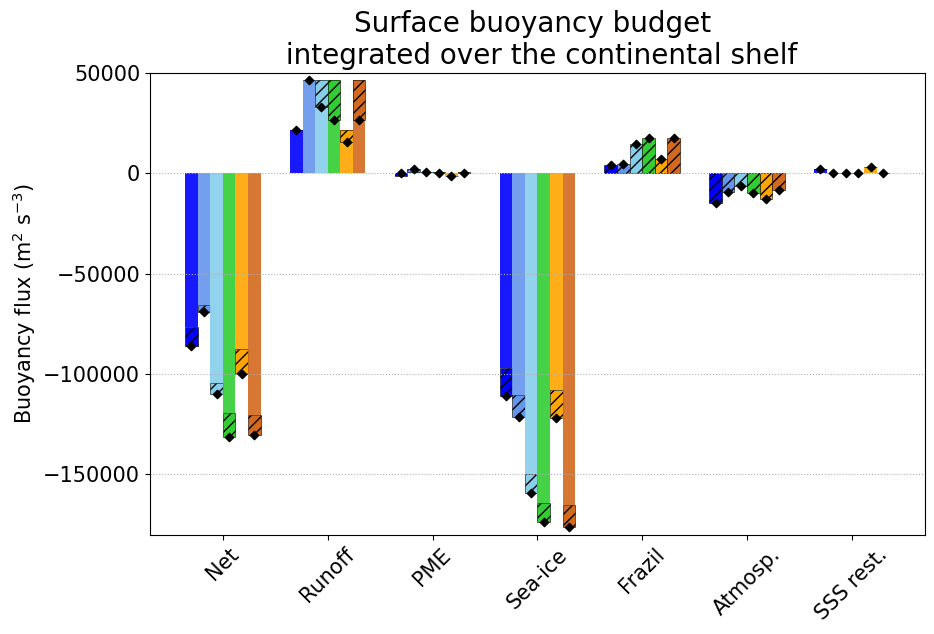

In [26]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

terms = list(Buoy_FW.keys())
x = np.arange(len(terms))

width = 0.12

colors = [
        'blue',
        'cornflowerblue',
        'skyblue',
        'limegreen',
        'orange',
        'chocolate'
]

labels = [
        r'SFC$_{CON}$',
        r'SFC$_{Antw}$',
        r'SFC$_{Antw\_LH}$',
        r'SFC_LH$_{Antw\_LH}$',
        r'BASAL_LH$_{CON\_LH}$',
        r'BASAL_LH$_{Antw\_LH}$'
]

fig, ax  = plt.subplots(figsize = (10,6))


for iexp in range(6):

    FW_vals = np.array(
    [
        np.asarray(Buoy_FW[t][iexp]).squeeze()
        for t in terms
    ],
    dtype=float
    )
    
    H_vals = np.array(
    [
        np.asarray(Buoy_H[t][iexp]).squeeze()
        for t in terms
    ],
    dtype=float
    )

    total_vals = FW_vals + H_vals

    xpos = x + (iexp-2.5)*width

    #
    # FW contribution
    #
    ax.bar(
        xpos,
        FW_vals,
        width=width,
        color=colors[iexp],
        alpha=0.9,
        label=labels[iexp]
    )

    #
    # Heat contribution
    #
    ax.bar(
        xpos,
        H_vals,
        width=width,
        bottom=FW_vals,
        color=colors[iexp],
        hatch='///',
        edgecolor='k',
        linewidth=0.4
    )

    #
    # Total buoyancy contribution
    #
    ax.scatter(
        xpos,
        total_vals,
        color='k',
        marker='D',
        s=18,
        zorder=10
    )



extra_legend = [

    Patch(
        facecolor='lightgrey',
        label='Freshwater'
    ),

    Patch(
        facecolor='lightgrey',
        hatch='///',
        edgecolor='k',
        label='Heat'
    ),

    Line2D(
        [0],[0],
        marker='D',
        color='k',
        linestyle='None',
        label='Total'
    )

]

ax.set_xticks(np.arange(0,7),('Net','Runoff','PME','Sea-ice','Frazil',
                              'Atmosp.','SSS rest.'),rotation=45,fontsize=20) #,'Brine'),rotation=45)

plt.title('Surface buoyancy budget \n integrated over the continental shelf',fontsize=20)
    
ax.set_ylabel(r'Buoyancy flux (m$^2$ s$^{-3}$)',fontsize=15)
ax.tick_params(labelsize=15)
ax.grid(True, axis='y', linestyle=':')
ax.set_ylim(-180000,50000)

### Save fig
plt.savefig(figdir+'SBuoyBudget+HeatFWdecomp_annual_hint_shelf_yr17-20_Antwater_winter.png',bbox_inches='tight',dpi=300)
plt.show()


### Read DSW regional integral

In [36]:
# budget_dir = '/g/data/e14/fbd581/basal_mom5-collaborative-project/budget_integrated/'
budget_dir = '/g/data/e14/fbd581/basal_mom5-collaborative-project/budget_integrated_winter/'
# budget_dir = '/g/data/e14/fbd581/basal_mom5-collaborative-project/budget_integrated_LargeRegion/'
# budget_dir = '/g/data/e14/fbd581/basal_mom5-collaborative-project/budget_integrated_LargeRegion_winter/'

# print(xr.open_dataset(budget_dir+'river_annual_hint_region_ctrl.nc'))

In [37]:
import os

datasets = {}

for f in glob.glob(budget_dir + '*.nc'):

    key = os.path.basename(f).replace('.nc','')

    datasets[key] = xr.open_dataset(f)

In [38]:
def val(term, exp, region):

    dsname = f'{term}_annual_hint_region_{exp}'

    return datasets[dsname][region].item()


0
1
2
3


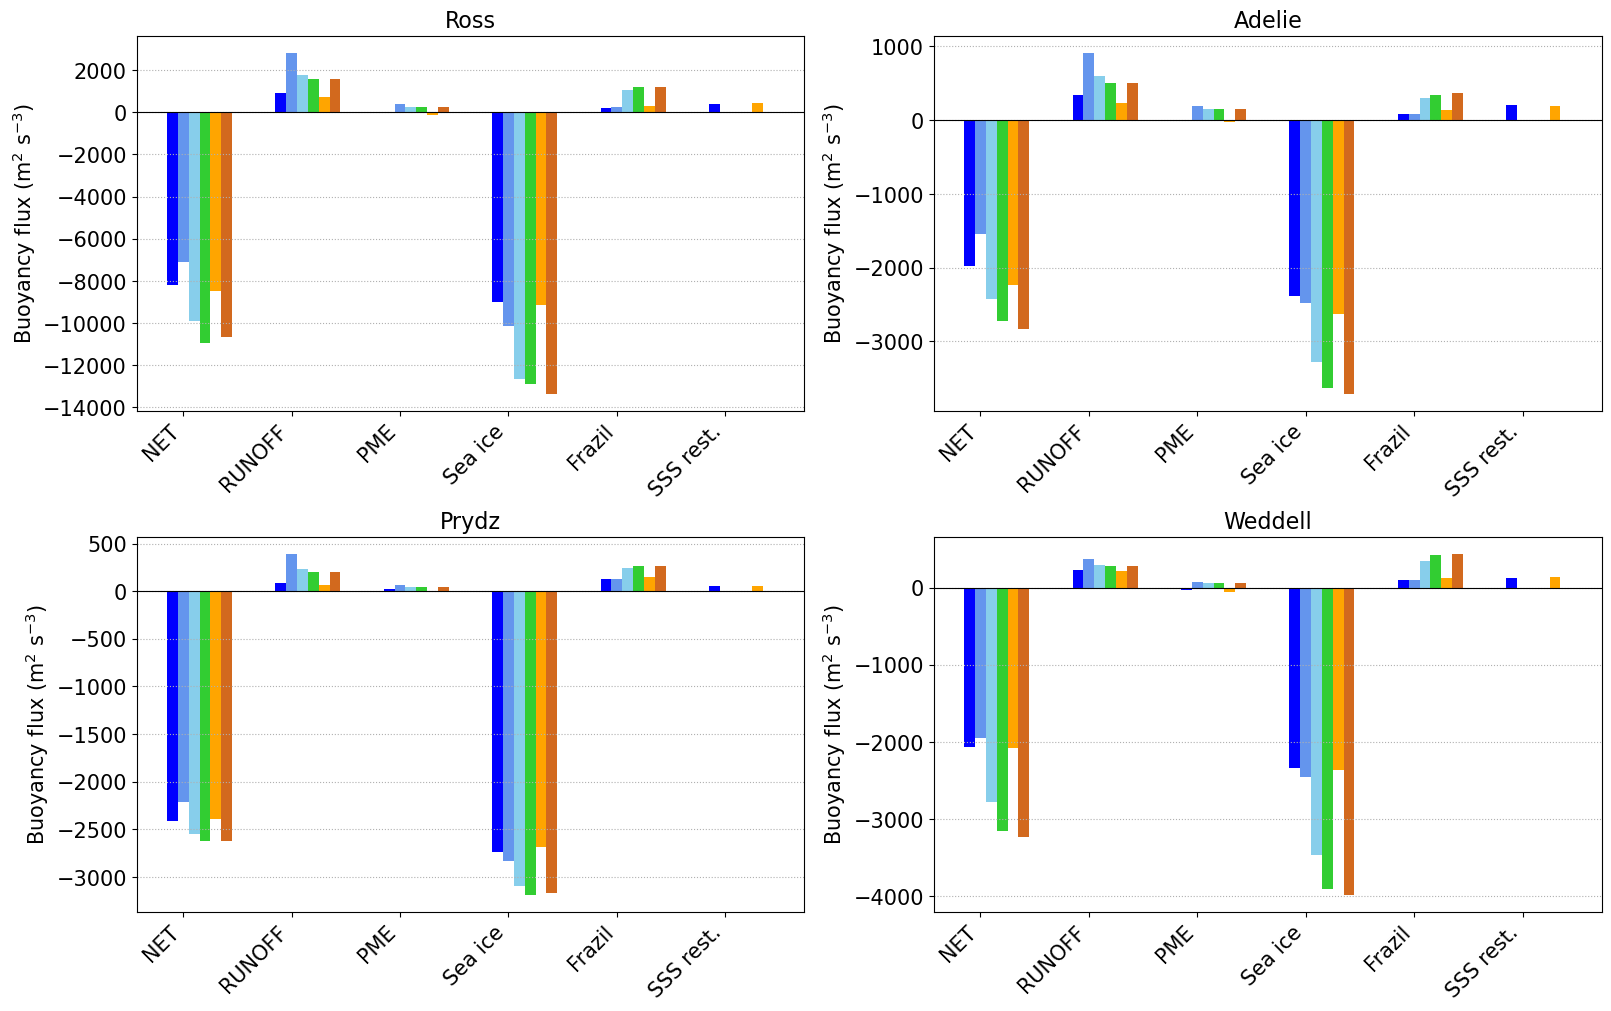

In [39]:
regions = ['Ross','Adelie','Prydz','Weddell']

fig, axs = plt.subplots(
    2, 2,
    figsize=(16,10),
    constrained_layout=True
)

for i, region in enumerate(regions):

    print(i)
    if i == 0:
        ax = axs[0,0]
    elif i == 1:
        ax = axs[0,1]
    elif i == 2:
        ax = axs[1,0]
    elif i == 3:
        ax = axs[1,1]

    #
    # FW budget
    #

    # NET
    FW_net_ctrl = val('pme_river','ctrl',region)
    FW_net_ctrl_a = val('pme_river','ctrl_a',region)
    FW_net_ctrl_a_BG = val('pme_river','ctrl_a_BG',region) + val('basal','ctrl_a_BG',region) + val('brine','ctrl_a_BG',region)
    FW_net_ctrlBG_a  = val('pme_river','ctrlBG_a',region) + val('basal','ctrlBG_a',region) + val('brine','ctrlBG_a',region)
    FW_net_BGB = val('pme_river','BGB',region) + val('basal','BGB',region) + val('brine','BGB',region)
    FW_net_BGB_a = val('pme_river','BGB_a',region) + val('basal','BGB_a',region) + val('brine','BGB_a',region)
    
    # PME
    pme_ctrl = val('pme_net','ctrl',region) - (val('wfiform','ctrl',region) + val('wfimelt','ctrl',region))
    pme_ctrl_a = val('pme_net','ctrl_a',region)  - (val('wfiform','ctrl_a',region) + val('wfimelt','ctrl_a',region))
    pme_ctrl_a_BG = val('pme_net','ctrl_a_BG',region) + val('brine','ctrl_a_BG',region) - (val('wfiform','ctrl_a_BG',region) + val('wfimelt','ctrl_a_BG',region))
    pme_ctrlBG_a  = val('pme_net','ctrlBG_a',region) + val('brine','ctrlBG_a',region) - (val('wfiform','ctrlBG_a',region) + val('wfimelt','ctrlBG_a',region))
    pme_BGB = val('pme_net','BGB',region) + val('brine','BGB',region)  - (val('wfiform','BGB',region) + val('wfimelt','BGB',region))
    pme_BGB_a = val('pme_net','BGB_a',region) + val('brine','BGB_a',region)  - (val('wfiform','BGB_a',region) + val('wfimelt','BGB_a',region))
    
    # Runoff
    runoff_ctrl = val('river','ctrl',region)
    runoff_ctrl_a = val('river','ctrl_a',region)
    runoff_ctrl_a_BG = val('river','ctrl_a_BG',region) + val('basal','ctrl_a_BG',region)
    runoff_ctrlBG_a  = val('river','ctrlBG_a',region) + val('basal','ctrlBG_a',region)
    runoff_BGB = val('river','BGB',region) + val('basal','BGB',region)
    runoff_BGB_a = val('river','BGB_a',region) + val('basal','BGB_a',region)
    
    # Sea ice (net)
    FW_SI_ctrl = (val('wfiform','ctrl',region) + val('wfimelt','ctrl',region))
    FW_SI_ctrl_a = (val('wfiform','ctrl_a',region) + val('wfimelt','ctrl_a',region))
    FW_SI_ctrl_a_BG = (val('wfiform','ctrl_a_BG',region) + val('wfimelt','ctrl_a_BG',region))
    FW_SI_ctrlBG_a =  (val('wfiform','ctrlBG_a',region) + val('wfimelt','ctrlBG_a',region))
    FW_SI_BGB = (val('wfiform','BGB',region) + val('wfimelt','BGB',region))
    FW_SI_BGB_a = (val('wfiform','BGB_a',region) + val('wfimelt','BGB_a',region))
    
    # SSS restoring
    SSSrest_ctrl = val('FW_restore','ctrl',region)
    SSSrest_ctrl_a = val('FW_restore','ctrl_a',region)
    SSSrest_ctrl_a_BG = val('FW_restore','ctrl_a_BG',region)
    SSSrest_ctrlBG_a = val('FW_restore','ctrlBG_a',region)
    SSSrest_BGB = val('FW_restore','BGB',region)
    SSSrest_BGB_a = val('FW_restore','BGB_a',region)

    # FW from ice
    Ice_ctrl = val('FW_ice','ctrl',region)
    Ice_ctrl_a = val('FW_ice','ctrl_a',region)
    Ice_ctrl_a_BG = val('FW_ice','ctrl_a_BG',region)
    Ice_ctrlBG_a = val('FW_ice','ctrlBG_a',region)
    Ice_BGB = val('FW_ice','BGB',region)
    Ice_BGB_a = val('FW_ice','BGB_a',region)

    #
    # Heat budget
    #

    # Runoff
    HF_runoff_ctrl = val('HF_runoff','ctrl',region)
    HF_runoff_ctrl_a = val('HF_runoff','ctrl_a',region)
    HF_runoff_ctrl_a_BG = val('HF_runoff','ctrl_a_BG',region) 
    HF_runoff_ctrlBG_a = val('HF_runoff','ctrlBG_a',region) 
    HF_runoff_BGB = val('HF_runoff','BGB',region) 
    HF_runoff_BGB_a = val('HF_runoff','BGB_a',region)
    
    # Atmosp. (incl. SI)
    HF_coupler_ctrl = val('HF_coupler','ctrl',region) - val('HF_mh','ctrl',region)
    HF_coupler_ctrl_a = val('HF_coupler','ctrl_a',region) - val('HF_mh','ctrl_a',region)
    HF_coupler_ctrl_a_BG = val('HF_coupler','ctrl_a_BG',region) - val('HF_mh','ctrl_a_BG',region)
    HF_coupler_ctrlBG_a = val('HF_coupler','ctrlBG_a',region) - val('HF_mh','ctrlBG_a',region)
    HF_coupler_BGB = val('HF_coupler','BGB',region) - val('HF_mh','BGB',region)
    HF_coupler_BGB_a = val('HF_coupler','BGB_a',region) - val('HF_mh','BGB_a',region)
    
    # basalmix
    # basal_ctrl = val('HF_basalmix','ctrl',region)
    # basal_ctrl_a = val('HF_basalmix','ctrl_a',region)
    HF_basal_ctrl_a_BG = val('HF_basalmix','ctrl_a_BG',region)
    HF_basal_ctrlBG_a = val('HF_basalmix','ctrlBG_a',region)
    HF_basal_BGB = val('HF_basalmix','BGB',region)
    HF_basal_BGB_a = val('HF_basalmix','BGB_a',region)
    
    # PME
    HF_pme_ctrl = val('HF_pme','ctrl',region) 
    HF_pme_ctrl_a = val('HF_pme','ctrl_a',region)  
    HF_pme_ctrl_a_BG = val('HF_pme','ctrl_a_BG',region) 
    HF_pme_ctrlBG_a = val('HF_pme','ctrlBG_a',region) 
    HF_pme_BGB = val('HF_pme','BGB',region) 
    HF_pme_BGB_a = val('HF_pme','BGB_a',region) 
    
    # Frazil
    HF_frazil_ctrl = val('HF_frazil','ctrl',region)
    HF_frazil_ctrl_a = val('HF_frazil','ctrl_a',region)
    HF_frazil_ctrl_a_BG = val('HF_frazil','ctrl_a_BG',region)
    HF_frazil_ctrlBG_a = val('HF_frazil','ctrlBG_a',region)
    HF_frazil_BGB = val('HF_frazil','BGB',region)
    HF_frazil_BGB_a = val('HF_frazil','BGB_a',region)
    
    # Sea-ice
    HF_mh_ctrl = val('HF_mh','ctrl',region)
    HF_mh_ctrl_a = val('HF_mh','ctrl_a',region)
    HF_mh_ctrl_a_BG = val('HF_mh','ctrl_a_BG',region)
    HF_mh_ctrlBG_a = val('HF_mh','ctrlBG_a',region)
    HF_mh_BGB = val('HF_mh','BGB',region)
    HF_mh_BGB_a = val('HF_mh','BGB_a',region)
    
    # NET
    HF_net_ctrl = HF_runoff_ctrl + HF_coupler_ctrl + HF_pme_ctrl + HF_frazil_ctrl
    HF_net_ctrl_a = HF_runoff_ctrl_a + HF_coupler_ctrl_a + HF_pme_ctrl_a + HF_frazil_ctrl_a
    HF_net_ctrl_a_BG = HF_runoff_ctrl_a_BG + HF_coupler_ctrl_a_BG + HF_pme_ctrl_a_BG + HF_frazil_ctrl_a_BG + HF_basal_ctrl_a_BG
    HF_net_ctrlBG_a = HF_runoff_ctrlBG_a + HF_coupler_ctrlBG_a + HF_pme_ctrlBG_a + HF_frazil_ctrlBG_a + HF_basal_ctrlBG_a
    HF_net_BGB = HF_runoff_BGB + HF_coupler_BGB + HF_pme_BGB + HF_frazil_BGB + HF_basal_BGB
    HF_net_BGB_a = HF_runoff_BGB_a + HF_coupler_BGB_a + HF_pme_BGB_a + HF_frazil_BGB_a + HF_basal_BGB_a

    # ------Combined terms & converting to buoyancy budget:
    # ctrl
    NET_BH_ctrl = HF_net_ctrl*heat_cte 
    NET_BFW_ctrl = FW_net_ctrl*fw_cte
    NET_ctrl = NET_BH_ctrl + NET_BFW_ctrl
    RUNOFF_BH_ctrl = HF_runoff_ctrl*heat_cte
    RUNOFF_BFW_ctrl = (runoff_ctrl)*fw_cte           
    RUNOFF_ctrl = RUNOFF_BH_ctrl + RUNOFF_BFW_ctrl    
    PME_BH_ctrl = HF_pme_ctrl*heat_cte
    PME_BFW_ctrl = pme_ctrl*fw_cte 
    PME_ctrl = PME_BH_ctrl + PME_BFW_ctrl    
    SI_BH_ctrl = HF_mh_ctrl*heat_cte
    SI_BFW_ctrl = FW_SI_ctrl*fw_cte
    SI_ctrl = SI_BH_ctrl + SI_BFW_ctrl
    FRAZIL_BH_ctrl = HF_frazil_ctrl*heat_cte    
    SSSrest_BFW_ctrl = SSSrest_ctrl*fw_cte
    # ctrl_a
    NET_BH_ctrl_a = HF_net_ctrl_a*heat_cte 
    NET_BFW_ctrl_a = FW_net_ctrl_a*fw_cte
    NET_ctrl_a = NET_BH_ctrl_a + NET_BFW_ctrl_a
    RUNOFF_BH_ctrl_a = HF_runoff_ctrl_a*heat_cte
    RUNOFF_BFW_ctrl_a = (runoff_ctrl_a)*fw_cte           
    RUNOFF_ctrl_a = RUNOFF_BH_ctrl_a + RUNOFF_BFW_ctrl_a
    PME_BH_ctrl_a = HF_pme_ctrl_a*heat_cte
    PME_BFW_ctrl_a = pme_ctrl_a*fw_cte 
    PME_ctrl_a = PME_BH_ctrl_a + PME_BFW_ctrl_a
    SI_BH_ctrl_a = HF_mh_ctrl_a*heat_cte
    SI_BFW_ctrl_a = FW_SI_ctrl_a*fw_cte
    SI_ctrl_a = SI_BH_ctrl_a + SI_BFW_ctrl_a
    FRAZIL_BH_ctrl_a = HF_frazil_ctrl_a*heat_cte
    SSSrest_BFW_ctrl_a = SSSrest_ctrl_a*fw_cte
    # ctrl_a_BG
    NET_BH_ctrl_a_BG = HF_net_ctrl_a_BG*heat_cte 
    NET_BFW_ctrl_a_BG = FW_net_ctrl_a_BG*fw_cte
    NET_ctrl_a_BG = NET_BH_ctrl_a_BG + NET_BFW_ctrl_a_BG
    RUNOFF_BH_ctrl_a_BG = HF_runoff_ctrl_a_BG*heat_cte + HF_basal_ctrl_a_BG*heat_cte
    RUNOFF_BFW_ctrl_a_BG = (runoff_ctrl_a_BG)*fw_cte           
    RUNOFF_ctrl_a_BG = RUNOFF_BH_ctrl_a_BG + RUNOFF_BFW_ctrl_a_BG
    PME_BH_ctrl_a_BG = HF_pme_ctrl_a_BG*heat_cte
    PME_BFW_ctrl_a_BG = pme_ctrl_a_BG*fw_cte 
    PME_ctrl_a_BG = PME_BH_ctrl_a_BG + PME_BFW_ctrl_a_BG
    SI_BH_ctrl_a_BG = HF_mh_ctrl_a_BG*heat_cte
    SI_BFW_ctrl_a_BG = FW_SI_ctrl_a_BG*fw_cte
    SI_ctrl_a_BG = SI_BH_ctrl_a_BG + SI_BFW_ctrl_a_BG
    FRAZIL_BH_ctrl_a_BG = HF_frazil_ctrl_a_BG*heat_cte
    SSSrest_BFW_ctrl_a_BG = SSSrest_ctrl_a_BG*fw_cte
    # ctrlBG_a
    NET_BH_ctrlBG_a = HF_net_ctrlBG_a*heat_cte 
    NET_BFW_ctrlBG_a = FW_net_ctrlBG_a*fw_cte
    NET_ctrlBG_a = NET_BH_ctrlBG_a + NET_BFW_ctrlBG_a
    RUNOFF_BH_ctrlBG_a = HF_runoff_ctrlBG_a*heat_cte + HF_basal_ctrlBG_a*heat_cte
    RUNOFF_BFW_ctrlBG_a = (runoff_ctrlBG_a)*fw_cte           
    RUNOFF_ctrlBG_a = RUNOFF_BH_ctrlBG_a + RUNOFF_BFW_ctrlBG_a
    PME_BH_ctrlBG_a = HF_pme_ctrlBG_a*heat_cte
    PME_BFW_ctrlBG_a = pme_ctrlBG_a*fw_cte 
    PME_ctrlBG_a = PME_BH_ctrlBG_a + PME_BFW_ctrlBG_a
    SI_BH_ctrlBG_a = HF_mh_ctrlBG_a*heat_cte
    SI_BFW_ctrlBG_a = FW_SI_ctrlBG_a*fw_cte
    SI_ctrlBG_a = SI_BH_ctrlBG_a + SI_BFW_ctrlBG_a
    FRAZIL_BH_ctrlBG_a = HF_frazil_ctrlBG_a*heat_cte
    SSSrest_BFW_ctrlBG_a = SSSrest_ctrlBG_a*fw_cte
    # BGB
    NET_BH_BGB = HF_net_BGB*heat_cte 
    NET_BFW_BGB = FW_net_BGB*fw_cte
    NET_BGB = NET_BH_BGB + NET_BFW_BGB
    RUNOFF_BH_BGB = HF_runoff_BGB*heat_cte + HF_basal_BGB*heat_cte
    RUNOFF_BFW_BGB = (runoff_BGB)*fw_cte           
    RUNOFF_BGB = RUNOFF_BH_BGB + RUNOFF_BFW_BGB
    PME_BH_BGB = HF_pme_BGB*heat_cte
    PME_BFW_BGB = pme_BGB*fw_cte 
    PME_BGB = PME_BH_BGB + PME_BFW_BGB
    SI_BH_BGB = HF_mh_BGB*heat_cte
    SI_BFW_BGB = FW_SI_BGB*fw_cte
    SI_BGB = SI_BH_BGB + SI_BFW_BGB
    FRAZIL_BH_BGB = HF_frazil_BGB*heat_cte
    SSSrest_BFW_BGB = SSSrest_BGB*fw_cte
    # BGB_a
    NET_BH_BGB_a = HF_net_BGB_a*heat_cte 
    NET_BFW_BGB_a = FW_net_BGB_a*fw_cte
    NET_BGB_a = NET_BH_BGB_a + NET_BFW_BGB_a
    RUNOFF_BH_BGB_a = HF_runoff_BGB_a*heat_cte  + HF_basal_BGB_a*heat_cte
    RUNOFF_BFW_BGB_a = (runoff_BGB_a)*fw_cte           
    RUNOFF_BGB_a = RUNOFF_BH_BGB_a + RUNOFF_BFW_BGB_a
    PME_BH_BGB_a = HF_pme_BGB_a*heat_cte
    PME_BFW_BGB_a = pme_BGB_a*fw_cte 
    PME_BGB_a = PME_BH_BGB_a + PME_BFW_BGB_a
    SI_BH_BGB_a = HF_mh_BGB_a*heat_cte
    SI_BFW_BGB_a = FW_SI_BGB_a*fw_cte
    SI_BGB_a = SI_BH_BGB_a + SI_BFW_BGB_a
    FRAZIL_BH_BGB_a = HF_frazil_BGB_a*heat_cte
    SSSrest_BFW_BGB_a = SSSrest_BGB_a*fw_cte


### ---- combine for plotting:
    
    Buoy_budget = {
    'NET': [
        np.asarray(NET_ctrl).item(),
        np.asarray(NET_ctrl_a).item(),
        np.asarray(NET_ctrl_a_BG).item(),
        np.asarray(NET_ctrlBG_a).item(),
        np.asarray(NET_BGB).item(),
        np.asarray(NET_BGB_a).item(),
    ],

    'RUNOFF': [
        RUNOFF_ctrl,
        RUNOFF_ctrl_a,
        RUNOFF_ctrl_a_BG,
        RUNOFF_ctrlBG_a,
        RUNOFF_BGB,
        RUNOFF_BGB_a,
    ],
        
    'PME': [
        PME_ctrl,
        PME_ctrl_a,
        PME_ctrl_a_BG,
        PME_ctrlBG_a,
        PME_BGB,
        PME_BGB_a,
    ],

    'Sea ice': [
        SI_ctrl,
        SI_ctrl_a,
        SI_ctrl_a_BG,
        SI_ctrlBG_a,
        SI_BGB,
        SI_BGB_a,
    ],

    'Frazil': [
        FRAZIL_BH_ctrl,
        FRAZIL_BH_ctrl_a,
        FRAZIL_BH_ctrl_a_BG,
        FRAZIL_BH_ctrlBG_a,
        FRAZIL_BH_BGB,
        FRAZIL_BH_BGB_a,
    ],

    'SSS rest.': [
        SSSrest_BFW_ctrl,
        SSSrest_BFW_ctrl_a,
        SSSrest_BFW_ctrl_a_BG,
        SSSrest_BFW_ctrlBG_a,
        SSSrest_BFW_BGB,
        SSSrest_BFW_BGB_a,
    ],

}

    terms = list(Buoy_budget.keys())
    x = np.arange(len(terms))
    
    width = 0.1
    
    colors = [
        'blue',
        'cornflowerblue',
        'skyblue',
        'limegreen',
        'orange',
        'chocolate'
    ]
    
    labels = [
        r'SFC$_{CON}$',
        r'SFC$_{Antw}$',
        r'SFC$_{Antw\_LH}$',
        r'SFC_LH$_{Antw\_LH}$',
        r'BASAL_LH$_{CON\_LH}$',
        r'BASAL_LH$_{Antw\_LH}$'
    ]
    
    for iexp in range(6):
    
        vals = [Buoy_budget[t][iexp] for t in terms]

        ax.bar(
            x + (iexp-1)*width,
            (vals),
            width=width,
            color=colors[iexp],
            label=labels[iexp]
        )
    
    ax.axhline(0, color='k', linewidth=0.8)
    
    ax.set_xticks(x)
    ax.set_xticklabels(
        terms,
        rotation=45,
        ha='right',
        fontsize=15
    )
    
    ax.set_ylabel(r'Buoyancy flux (m$^2$ s$^{-3}$)',fontsize=15)
        
    ax.set_title(f'{region}',fontsize=16)
    
    ax.grid(True, axis='y', linestyle=':')
    # if region == 'Ross':
    #     ax.legend(fontsize=12)
    #     ax.set_ylim(-40e12,10e12) ## for W units
    # else:
    #     ax.set_ylim(-6e12,6e12) ## for W units
    
    ax.tick_params(labelsize=15)
    
    # ax.set_ylim(-2.5e7,1.5e7)
    # ax.set_ylim(-40e12,10e12) ## for W units

    # ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

## Save fig
plt.savefig(figdir+'SBuoyBudget_annual_shelf_yr17-20_DSWregions_abs_winter.png',bbox_inches='tight',dpi=300)
plt.show()


0
1
2
3


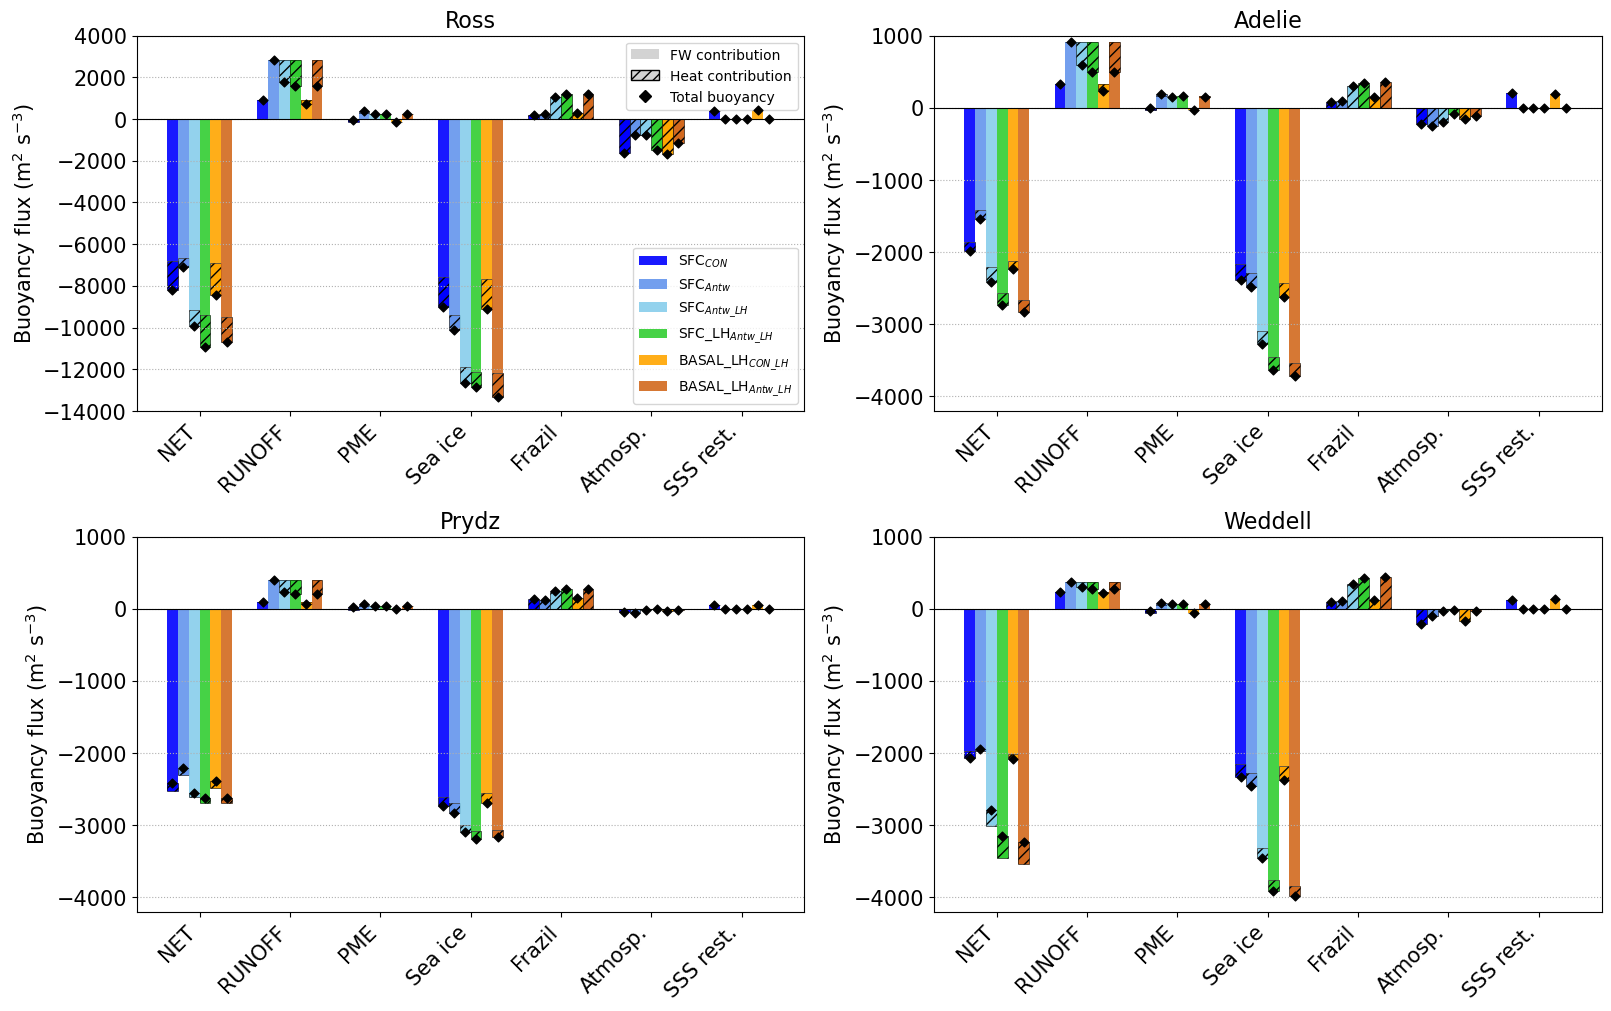

In [40]:
regions = ['Ross','Adelie','Prydz','Weddell']

fig, axs = plt.subplots(
    2, 2,
    figsize=(16,10),
    constrained_layout=True
)

for i, region in enumerate(regions):

    print(i)
    if i == 0:
        ax = axs[0,0]
    elif i == 1:
        ax = axs[0,1]
    elif i == 2:
        ax = axs[1,0]
    elif i == 3:
        ax = axs[1,1]

    #
    # FW budget
    #

    # NET
    FW_net_ctrl = val('pme_river','ctrl',region)
    FW_net_ctrl_a = val('pme_river','ctrl_a',region)
    FW_net_ctrl_a_BG = val('pme_river','ctrl_a_BG',region) + val('basal','ctrl_a_BG',region) + val('brine','ctrl_a_BG',region)
    FW_net_ctrlBG_a  = val('pme_river','ctrlBG_a',region) + val('basal','ctrlBG_a',region) + val('brine','ctrlBG_a',region)
    FW_net_BGB = val('pme_river','BGB',region) + val('basal','BGB',region) + val('brine','BGB',region)
    FW_net_BGB_a = val('pme_river','BGB_a',region) + val('basal','BGB_a',region) + val('brine','BGB_a',region)
    
    # PME
    pme_ctrl = val('pme_net','ctrl',region) - (val('wfiform','ctrl',region) + val('wfimelt','ctrl',region))
    pme_ctrl_a = val('pme_net','ctrl_a',region)  - (val('wfiform','ctrl_a',region) + val('wfimelt','ctrl_a',region))
    pme_ctrl_a_BG = val('pme_net','ctrl_a_BG',region) + val('brine','ctrl_a_BG',region) - (val('wfiform','ctrl_a_BG',region) + val('wfimelt','ctrl_a_BG',region))
    pme_ctrlBG_a  = val('pme_net','ctrlBG_a',region) + val('brine','ctrlBG_a',region) - (val('wfiform','ctrlBG_a',region) + val('wfimelt','ctrlBG_a',region))
    pme_BGB = val('pme_net','BGB',region) + val('brine','BGB',region)  - (val('wfiform','BGB',region) + val('wfimelt','BGB',region))
    pme_BGB_a = val('pme_net','BGB_a',region) + val('brine','BGB_a',region)  - (val('wfiform','BGB_a',region) + val('wfimelt','BGB_a',region))
    
    # Runoff
    runoff_ctrl = val('river','ctrl',region)
    runoff_ctrl_a = val('river','ctrl_a',region)
    runoff_ctrl_a_BG = val('river','ctrl_a_BG',region) + val('basal','ctrl_a_BG',region)
    runoff_ctrlBG_a  = val('river','ctrlBG_a',region) + val('basal','ctrlBG_a',region)
    runoff_BGB = val('river','BGB',region) + val('basal','BGB',region)
    runoff_BGB_a = val('river','BGB_a',region) + val('basal','BGB_a',region)
    
    # Sea ice (net)
    FW_SI_ctrl = (val('wfiform','ctrl',region) + val('wfimelt','ctrl',region))
    FW_SI_ctrl_a = (val('wfiform','ctrl_a',region) + val('wfimelt','ctrl_a',region))
    FW_SI_ctrl_a_BG = (val('wfiform','ctrl_a_BG',region) + val('wfimelt','ctrl_a_BG',region))
    FW_SI_ctrlBG_a =  (val('wfiform','ctrlBG_a',region) + val('wfimelt','ctrlBG_a',region))
    FW_SI_BGB = (val('wfiform','BGB',region) + val('wfimelt','BGB',region))
    FW_SI_BGB_a = (val('wfiform','BGB_a',region) + val('wfimelt','BGB_a',region))
    
    # SSS restoring
    SSSrest_ctrl = val('FW_restore','ctrl',region)
    SSSrest_ctrl_a = val('FW_restore','ctrl_a',region)
    SSSrest_ctrl_a_BG = val('FW_restore','ctrl_a_BG',region)
    SSSrest_ctrlBG_a = val('FW_restore','ctrlBG_a',region)
    SSSrest_BGB = val('FW_restore','BGB',region)
    SSSrest_BGB_a = val('FW_restore','BGB_a',region)

    # FW from ice
    Ice_ctrl = val('FW_ice','ctrl',region)
    Ice_ctrl_a = val('FW_ice','ctrl_a',region)
    Ice_ctrl_a_BG = val('FW_ice','ctrl_a_BG',region)
    Ice_ctrlBG_a = val('FW_ice','ctrlBG_a',region)
    Ice_BGB = val('FW_ice','BGB',region)
    Ice_BGB_a = val('FW_ice','BGB_a',region)

    #
    # Heat budget
    #

    # Runoff
    HF_runoff_ctrl = val('HF_runoff','ctrl',region)
    HF_runoff_ctrl_a = val('HF_runoff','ctrl_a',region)
    HF_runoff_ctrl_a_BG = val('HF_runoff','ctrl_a_BG',region) 
    HF_runoff_ctrlBG_a = val('HF_runoff','ctrlBG_a',region) 
    HF_runoff_BGB = val('HF_runoff','BGB',region) 
    HF_runoff_BGB_a = val('HF_runoff','BGB_a',region)
    
    # Atmosp. (incl. SI)
    HF_coupler_ctrl = val('HF_coupler','ctrl',region) - val('HF_mh','ctrl',region)
    HF_coupler_ctrl_a = val('HF_coupler','ctrl_a',region) - val('HF_mh','ctrl_a',region)
    HF_coupler_ctrl_a_BG = val('HF_coupler','ctrl_a_BG',region) - val('HF_mh','ctrl_a_BG',region)
    HF_coupler_ctrlBG_a = val('HF_coupler','ctrlBG_a',region) - val('HF_mh','ctrlBG_a',region)
    HF_coupler_BGB = val('HF_coupler','BGB',region) - val('HF_mh','BGB',region)
    HF_coupler_BGB_a = val('HF_coupler','BGB_a',region) - val('HF_mh','BGB_a',region)
    
    # basalmix
    # basal_ctrl = val('HF_basalmix','ctrl',region)
    # basal_ctrl_a = val('HF_basalmix','ctrl_a',region)
    HF_basal_ctrl_a_BG = val('HF_basalmix','ctrl_a_BG',region)
    HF_basal_ctrlBG_a = val('HF_basalmix','ctrlBG_a',region)
    HF_basal_BGB = val('HF_basalmix','BGB',region)
    HF_basal_BGB_a = val('HF_basalmix','BGB_a',region)
    
    # PME
    HF_pme_ctrl = val('HF_pme','ctrl',region) 
    HF_pme_ctrl_a = val('HF_pme','ctrl_a',region)  
    HF_pme_ctrl_a_BG = val('HF_pme','ctrl_a_BG',region) 
    HF_pme_ctrlBG_a = val('HF_pme','ctrlBG_a',region) 
    HF_pme_BGB = val('HF_pme','BGB',region) 
    HF_pme_BGB_a = val('HF_pme','BGB_a',region) 
    
    # Frazil
    HF_frazil_ctrl = val('HF_frazil','ctrl',region)
    HF_frazil_ctrl_a = val('HF_frazil','ctrl_a',region)
    HF_frazil_ctrl_a_BG = val('HF_frazil','ctrl_a_BG',region)
    HF_frazil_ctrlBG_a = val('HF_frazil','ctrlBG_a',region)
    HF_frazil_BGB = val('HF_frazil','BGB',region)
    HF_frazil_BGB_a = val('HF_frazil','BGB_a',region)
    
    # Sea-ice
    HF_mh_ctrl = val('HF_mh','ctrl',region)
    HF_mh_ctrl_a = val('HF_mh','ctrl_a',region)
    HF_mh_ctrl_a_BG = val('HF_mh','ctrl_a_BG',region)
    HF_mh_ctrlBG_a = val('HF_mh','ctrlBG_a',region)
    HF_mh_BGB = val('HF_mh','BGB',region)
    HF_mh_BGB_a = val('HF_mh','BGB_a',region)
    
    # NET
    HF_net_ctrl = HF_runoff_ctrl + HF_coupler_ctrl + HF_pme_ctrl + HF_frazil_ctrl
    HF_net_ctrl_a = HF_runoff_ctrl_a + HF_coupler_ctrl_a + HF_pme_ctrl_a + HF_frazil_ctrl_a
    HF_net_ctrl_a_BG = HF_runoff_ctrl_a_BG + HF_coupler_ctrl_a_BG + HF_pme_ctrl_a_BG + HF_frazil_ctrl_a_BG + HF_basal_ctrl_a_BG
    HF_net_ctrlBG_a = HF_runoff_ctrlBG_a + HF_coupler_ctrlBG_a + HF_pme_ctrlBG_a + HF_frazil_ctrlBG_a + HF_basal_ctrlBG_a
    HF_net_BGB = HF_runoff_BGB + HF_coupler_BGB + HF_pme_BGB + HF_frazil_BGB + HF_basal_BGB
    HF_net_BGB_a = HF_runoff_BGB_a + HF_coupler_BGB_a + HF_pme_BGB_a + HF_frazil_BGB_a + HF_basal_BGB_a

    # ------Combined terms & converting to buoyancy budget:
    # ctrl
    NET_BH_ctrl = HF_net_ctrl*heat_cte 
    NET_BFW_ctrl = FW_net_ctrl*fw_cte
    NET_ctrl = NET_BH_ctrl + NET_BFW_ctrl
    RUNOFF_BH_ctrl = HF_runoff_ctrl*heat_cte
    RUNOFF_BFW_ctrl = (runoff_ctrl)*fw_cte           
    RUNOFF_ctrl = RUNOFF_BH_ctrl + RUNOFF_BFW_ctrl    
    PME_BH_ctrl = HF_pme_ctrl*heat_cte
    PME_BFW_ctrl = pme_ctrl*fw_cte 
    PME_ctrl = PME_BH_ctrl + PME_BFW_ctrl    
    SI_BH_ctrl = HF_mh_ctrl*heat_cte
    SI_BFW_ctrl = FW_SI_ctrl*fw_cte
    SI_ctrl = SI_BH_ctrl + SI_BFW_ctrl
    FRAZIL_BH_ctrl = HF_frazil_ctrl*heat_cte    
    SSSrest_BFW_ctrl = SSSrest_ctrl*fw_cte
    # ctrl_a
    NET_BH_ctrl_a = HF_net_ctrl_a*heat_cte 
    NET_BFW_ctrl_a = FW_net_ctrl_a*fw_cte
    NET_ctrl_a = NET_BH_ctrl_a + NET_BFW_ctrl_a
    RUNOFF_BH_ctrl_a = HF_runoff_ctrl_a*heat_cte
    RUNOFF_BFW_ctrl_a = (runoff_ctrl_a)*fw_cte           
    RUNOFF_ctrl_a = RUNOFF_BH_ctrl_a + RUNOFF_BFW_ctrl_a
    PME_BH_ctrl_a = HF_pme_ctrl_a*heat_cte
    PME_BFW_ctrl_a = pme_ctrl_a*fw_cte 
    PME_ctrl_a = PME_BH_ctrl_a + PME_BFW_ctrl_a
    SI_BH_ctrl_a = HF_mh_ctrl_a*heat_cte
    SI_BFW_ctrl_a = FW_SI_ctrl_a*fw_cte
    SI_ctrl_a = SI_BH_ctrl_a + SI_BFW_ctrl_a
    FRAZIL_BH_ctrl_a = HF_frazil_ctrl_a*heat_cte
    SSSrest_BFW_ctrl_a = SSSrest_ctrl_a*fw_cte
    # ctrl_a_BG
    NET_BH_ctrl_a_BG = HF_net_ctrl_a_BG*heat_cte 
    NET_BFW_ctrl_a_BG = FW_net_ctrl_a_BG*fw_cte
    NET_ctrl_a_BG = NET_BH_ctrl_a_BG + NET_BFW_ctrl_a_BG
    RUNOFF_BH_ctrl_a_BG = HF_runoff_ctrl_a_BG*heat_cte  + HF_basal_ctrl_a_BG*heat_cte
    RUNOFF_BFW_ctrl_a_BG = (runoff_ctrl_a_BG)*fw_cte           
    RUNOFF_ctrl_a_BG = RUNOFF_BH_ctrl_a_BG + RUNOFF_BFW_ctrl_a_BG
    PME_BH_ctrl_a_BG = HF_pme_ctrl_a_BG*heat_cte
    PME_BFW_ctrl_a_BG = pme_ctrl_a_BG*fw_cte 
    PME_ctrl_a_BG = PME_BH_ctrl_a_BG + PME_BFW_ctrl_a_BG
    SI_BH_ctrl_a_BG = HF_mh_ctrl_a_BG*heat_cte
    SI_BFW_ctrl_a_BG = FW_SI_ctrl_a_BG*fw_cte
    SI_ctrl_a_BG = SI_BH_ctrl_a_BG + SI_BFW_ctrl_a_BG
    FRAZIL_BH_ctrl_a_BG = HF_frazil_ctrl_a_BG*heat_cte
    SSSrest_BFW_ctrl_a_BG = SSSrest_ctrl_a_BG*fw_cte
    # ctrlBG_a
    NET_BH_ctrlBG_a = HF_net_ctrlBG_a*heat_cte 
    NET_BFW_ctrlBG_a = FW_net_ctrlBG_a*fw_cte
    NET_ctrlBG_a = NET_BH_ctrlBG_a + NET_BFW_ctrlBG_a
    RUNOFF_BH_ctrlBG_a = HF_runoff_ctrlBG_a*heat_cte  + HF_basal_ctrlBG_a*heat_cte
    RUNOFF_BFW_ctrlBG_a = (runoff_ctrlBG_a)*fw_cte           
    RUNOFF_ctrlBG_a = RUNOFF_BH_ctrlBG_a + RUNOFF_BFW_ctrlBG_a
    PME_BH_ctrlBG_a = HF_pme_ctrlBG_a*heat_cte
    PME_BFW_ctrlBG_a = pme_ctrlBG_a*fw_cte 
    PME_ctrlBG_a = PME_BH_ctrlBG_a + PME_BFW_ctrlBG_a
    SI_BH_ctrlBG_a = HF_mh_ctrlBG_a*heat_cte
    SI_BFW_ctrlBG_a = FW_SI_ctrlBG_a*fw_cte
    SI_ctrlBG_a = SI_BH_ctrlBG_a + SI_BFW_ctrlBG_a
    FRAZIL_BH_ctrlBG_a = HF_frazil_ctrlBG_a*heat_cte
    SSSrest_BFW_ctrlBG_a = SSSrest_ctrlBG_a*fw_cte
    # BGB
    NET_BH_BGB = HF_net_BGB*heat_cte 
    NET_BFW_BGB = FW_net_BGB*fw_cte
    NET_BGB = NET_BH_BGB + NET_BFW_BGB
    RUNOFF_BH_BGB = HF_runoff_BGB*heat_cte  + HF_basal_BGB*heat_cte
    RUNOFF_BFW_BGB = (runoff_BGB)*fw_cte           
    RUNOFF_BGB = RUNOFF_BH_BGB + RUNOFF_BFW_BGB
    PME_BH_BGB = HF_pme_BGB*heat_cte
    PME_BFW_BGB = pme_BGB*fw_cte 
    PME_BGB = PME_BH_BGB + PME_BFW_BGB
    SI_BH_BGB = HF_mh_BGB*heat_cte
    SI_BFW_BGB = FW_SI_BGB*fw_cte
    SI_BGB = SI_BH_BGB + SI_BFW_BGB
    FRAZIL_BH_BGB = HF_frazil_BGB*heat_cte
    SSSrest_BFW_BGB = SSSrest_BGB*fw_cte
    # BGB_a
    NET_BH_BGB_a = HF_net_BGB_a*heat_cte 
    NET_BFW_BGB_a = FW_net_BGB_a*fw_cte
    NET_BGB_a = NET_BH_BGB_a + NET_BFW_BGB_a
    RUNOFF_BH_BGB_a = HF_runoff_BGB_a*heat_cte + HF_basal_BGB_a*heat_cte
    RUNOFF_BFW_BGB_a = (runoff_BGB_a)*fw_cte           
    RUNOFF_BGB_a = RUNOFF_BH_BGB_a + RUNOFF_BFW_BGB_a
    PME_BH_BGB_a = HF_pme_BGB_a*heat_cte
    PME_BFW_BGB_a = pme_BGB_a*fw_cte 
    PME_BGB_a = PME_BH_BGB_a + PME_BFW_BGB_a
    SI_BH_BGB_a = HF_mh_BGB_a*heat_cte
    SI_BFW_BGB_a = FW_SI_BGB_a*fw_cte
    SI_BGB_a = SI_BH_BGB_a + SI_BFW_BGB_a
    FRAZIL_BH_BGB_a = HF_frazil_BGB_a*heat_cte
    SSSrest_BFW_BGB_a = SSSrest_BGB_a*fw_cte


    Buoy_FW = {
    
        'NET': [NET_BFW_ctrl, NET_BFW_ctrl_a, NET_BFW_ctrl_a_BG,
                NET_BFW_ctrlBG_a, NET_BFW_BGB, NET_BFW_BGB_a],
    
        'RUNOFF': [RUNOFF_BFW_ctrl, RUNOFF_BFW_ctrl_a, RUNOFF_BFW_ctrl_a_BG,
                   RUNOFF_BFW_ctrlBG_a, RUNOFF_BFW_BGB, RUNOFF_BFW_BGB_a],
    
        'PME': [PME_BFW_ctrl, PME_BFW_ctrl_a, PME_BFW_ctrl_a_BG,
                PME_BFW_ctrlBG_a, PME_BFW_BGB, PME_BFW_BGB_a],
    
        'Sea ice': [SI_BFW_ctrl, SI_BFW_ctrl_a, SI_BFW_ctrl_a_BG,
                    SI_BFW_ctrlBG_a, SI_BFW_BGB, SI_BFW_BGB_a],
    
        'Frazil': [0,0,0,0,0,0],
    
        'Atmosp.': [0,0,0,0,0,0],
    
        'SSS rest.': [SSSrest_BFW_ctrl, SSSrest_BFW_ctrl_a,
                      SSSrest_BFW_ctrl_a_BG, SSSrest_BFW_ctrlBG_a,
                      SSSrest_BFW_BGB, SSSrest_BFW_BGB_a]
    }
    
    Buoy_H = {
    
        'NET': [NET_BH_ctrl, NET_BH_ctrl_a, NET_BH_ctrl_a_BG,
                NET_BH_ctrlBG_a, NET_BH_BGB, NET_BH_BGB_a],
    
        'RUNOFF': [RUNOFF_BH_ctrl, RUNOFF_BH_ctrl_a, RUNOFF_BH_ctrl_a_BG,
                   RUNOFF_BH_ctrlBG_a, RUNOFF_BH_BGB, RUNOFF_BH_BGB_a],
    
        'PME': [PME_BH_ctrl, PME_BH_ctrl_a, PME_BH_ctrl_a_BG,
                PME_BH_ctrlBG_a, PME_BH_BGB, PME_BH_BGB_a],
    
        'Sea ice': [SI_BH_ctrl, SI_BH_ctrl_a, SI_BH_ctrl_a_BG,
                    SI_BH_ctrlBG_a, SI_BH_BGB, SI_BH_BGB_a],
    
        'Frazil': [FRAZIL_BH_ctrl, FRAZIL_BH_ctrl_a,
                   FRAZIL_BH_ctrl_a_BG, FRAZIL_BH_ctrlBG_a,
                   FRAZIL_BH_BGB, FRAZIL_BH_BGB_a],
    
        'Atmosp.': [HF_coupler_ctrl*heat_cte,
                    HF_coupler_ctrl_a*heat_cte,
                    HF_coupler_ctrl_a_BG*heat_cte,
                    HF_coupler_ctrlBG_a*heat_cte,
                    HF_coupler_BGB*heat_cte,
                    HF_coupler_BGB_a*heat_cte],
    
        'SSS rest.': [0,0,0,0,0,0]
    }

    terms = list(Buoy_FW.keys())

    x = np.arange(len(terms))
    
    width = 0.12
    
    colors = [
        'blue',
        'cornflowerblue',
        'skyblue',
        'limegreen',
        'orange',
        'chocolate'
    ]

    for iexp in range(6):
    
        FW_vals = np.array(
            [Buoy_FW[t][iexp] for t in terms],
            dtype=float
        )
    
        H_vals = np.array(
            [Buoy_H[t][iexp] for t in terms],
            dtype=float
        )
    
        Total_vals = FW_vals + H_vals
    
        xpos = x + (iexp-2.5)*width
    
        #
        # freshwater contribution
        #
        ax.bar(
            xpos,
            FW_vals,
            width=width,
            color=colors[iexp],
            alpha=0.9,
            label=labels[iexp] if region == 'Ross' else None
        )
    
        #
        # heat contribution
        #
        ax.bar(
            xpos,
            H_vals,
            width=width,
            bottom=FW_vals,
            color=colors[iexp],
            hatch='///',
            edgecolor='k',
            linewidth=0.4
        )
    
        #
        # total buoyancy contribution
        #
        ax.scatter(
            xpos,
            Total_vals,
            marker='D',
            color='k',
            s=20,
            zorder=10
        )
    
    extra_handles = [
    
        Patch(
            facecolor='lightgrey',
            label='FW contribution'
        ),
    
        Patch(
            facecolor='lightgrey',
            hatch='///',
            edgecolor='k',
            label='Heat contribution'
        ),
    
        Line2D(
            [0],[0],
            marker='D',
            color='k',
            linestyle='None',
            label='Total buoyancy'
        )
    ]
    
    if region == 'Ross':
    
        exp_handles, exp_labels = ax.get_legend_handles_labels()
    
        leg1 = ax.legend(
            exp_handles,
            exp_labels,
            fontsize=10,
            loc='lower right'
        )
    
        ax.add_artist(leg1)
    
        ax.legend(
            handles=extra_handles,
            fontsize=10,
            loc='upper right'
        )
        
    ax.axhline(0, color='k', linewidth=0.8)
    
    ax.set_xticks(x)
    ax.set_xticklabels(
        terms,
        rotation=45,
        ha='right',
        fontsize=15
    )
    
    ax.set_ylabel(r'Buoyancy flux (m$^2$ s$^{-3}$)',fontsize=15)
        
    ax.set_title(f'{region}',fontsize=16)
    
    ax.grid(True, axis='y', linestyle=':')
    if region == 'Ross':
        # ax.legend(fontsize=12)
        ax.set_ylim(-14000,4000) ## for W units
    else:
        ax.set_ylim(-4200,1000) ## for W units
    
    ax.tick_params(labelsize=15)
    

## Save fig
plt.savefig(figdir+'SBuoyBudget+HeatFWdecomp_annual_shelf_yr17-20_DSWregions_abs_winter.png',bbox_inches='tight',dpi=300)
plt.show()